In [121]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt

In [122]:
# Set the overall style (e.g., 'whitegrid' for clean background with grid lines)
sns.set_theme(style='whitegrid', palette='muted')

# Scale the fonts and elements up so they are readable in a presentation
sns.set_context('talk')  # Options: 'paper', 'notebook', 'talk', 'poster'

# How do customer experiences connect to broader business outcomes?

## Basic Exploration

### Customer Support Tickets

In [123]:
customer_support_tickets = pd.read_csv(
    "/home/rushik-sriramoju/AtlassianDatathon/customer_support_tickets.csv"
)
all_customers = pd.read_csv("customers.csv")

In [124]:
cancellation_refund = customer_support_tickets[customer_support_tickets["Ticket Type"].isin(["Cancellation request", "Refund request"])]
churn_tickets_percentage = 100*(len(cancellation_refund)/len(customer_support_tickets))

print("Percentage of Tickets that are Cancellation/ Refund: ")
print(f"{round(churn_tickets_percentage, 2)}%")

Percentage of Tickets that are Cancellation/ Refund: 
40.7%


In [125]:

# Get the total number of customer ids
num_customers = len(all_customers["Customer ID"].unique())

# Get the total number of customers ids who decided to cancel
cancelled_customer_ids = pd.merge(
    cancellation_refund,
    all_customers,
    how="inner",
    on=["Customer Email", "Customer Name", "Customer Age", "Customer Gender"]
)

# Get the unique customers ids of customers who lodged a churn ticket
cancelled_customers_id_array = cancelled_customer_ids["Customer ID"].unique()

# Percentage of customers who are choosing to churn
print("Percentage of at-risk Customers: ")
print(f"{round(((len(cancelled_customers_id_array)/num_customers)*100), 2)}%")



Percentage of at-risk Customers: 
40.7%


In [126]:
customer_support_tickets["Ticket Subject"].value_counts()

Ticket Subject
Refund request                576
Software bug                  574
Product compatibility         567
Email delivery problem        561
Device compatibility issue    547
Loading issue                 542
Network problem               539
Installation support          530
Product setup                 529
Payment issue                 526
Product recommendation        517
Account access                509
Integration                   496
Data loss                     491
Cancellation request          487
Display issue                 478
Name: count, dtype: int64

In [127]:
customer_support_tickets["Ticket Type"].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [ ]:
# Get Loom tickets
customer_support_tickets_loom = customer_support_tickets[customer_support_tickets["Product Purchased"] == "Loom"]

# Get the loom tickets that are integration, email delivery and device compatibility
customer_support_tickets_loom_integration_email_device = customer_support_tickets[customer_support_tickets["Ticket Subject"].isin(["Integration", "Email Delivery Problem", "Device compatibility issue"])]

# Add a churn column
customer_support_tickets_loom_integration_email_device["Churn"] = customer_support_tickets_loom_integration_email_device["Ticket Type"].isin(["Cancellation request", "Refund request"])

# Select only churn customers
customer_support_tickets_loom_integration_email_device_churned = customer_support_tickets_loom_integration_email_device[customer_support_tickets_loom_integration_email_device["Churn"]]


# Get the total number of customers ids who decided to cancel
customer_support_tickets_loom_integration_email_device_churned_customers = pd.merge(
    customer_support_tickets_loom_integration_email_device_churned,
    all_customers,
    how="inner",
    on=["Customer Email", "Customer Name", "Customer Age", "Customer Gender"]
)

# Get the unique customers ids of customers who lodged a churn ticket
cancelled_customers_id_array = customer_support_tickets_loom_integration_email_device_churned_customers["Customer ID"].unique()

# Percentage of customers who are choosing to churn
print("Percentage of Churned Customers that lodged Integration, Email Delivery Problem, Device Compatibility: ")
print(f"{round(((len(cancelled_customers_id_array)/num_customers)*100), 2)}%")

print("Number of Churned Customers that lodged Integration, Email Delivery Problem, Device Compatibility: ")
print(len(cancelled_customers_id_array))

Percentage of Churned Customers that lodged Integration, Email Delivery Problem, Device Compatibility: 
5.26%
Number of Churned Customers that lodged Integration, Email Delivery Problem, Device Compatibility: 
438


In [129]:
customer_support_tickets["Customer Satisfaction Rating"].max()

np.float64(5.0)

In [130]:
product_usage = pd.read_csv(
    "/home/rushik-sriramoju/AtlassianDatathon/product_usage.csv"
)

product_usage.head()

,Customer ID,Product,Month,Active Days,Sessions,Product Actions,Collaborators,Integrations Used
0,CUST00001,Loom,2023-01,3,7,49,12,3
1,CUST00001,Loom,2023-02,4,7,22,4,4
2,CUST00001,Loom,2023-03,5,10,37,5,3
3,CUST00001,Loom,2023-04,4,7,47,12,1
4,CUST00001,Loom,2023-05,5,10,34,4,3


In [131]:
customer_support_tickets.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,Jira,22-03-2021,Technical issue,Product setup,Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,Confluence,22-05-2021,Technical issue,Integration,Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Trello,14-07-2020,Technical issue,Network problem,Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Loom,13-11-2020,Billing inquiry,Account access,Closed,Try capital clearly never color toward story.,Low,Social media,01-06-2023 07:29,01-06-2023 01:57,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Bitbucket,04-02-2020,Billing inquiry,Data loss,Closed,West decision evidence bit.,Low,Email,01-06-2023 00:12,01-06-2023 19:53,1.0


In [132]:
customer_support_tickets = customer_support_tickets.drop(columns=["Customer Email", "Ticket ID", "Customer Gender", "Date of Purchase", "Customer Age"])

In [133]:
customer_support_tickets.head()

,Customer Name,Product Purchased,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,Marisa Obrien,Jira,Technical issue,Product setup,Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN
1,Jessica Rios,Confluence,Technical issue,Integration,Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN
2,Christopher Robbins,Trello,Technical issue,Network problem,Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0
3,Christina Dillon,Loom,Billing inquiry,Account access,Closed,Try capital clearly never color toward story.,Low,Social media,01-06-2023 07:29,01-06-2023 01:57,3.0
4,Alexander Carroll,Bitbucket,Billing inquiry,Data loss,Closed,West decision evidence bit.,Low,Email,01-06-2023 00:12,01-06-2023 19:53,1.0


In [134]:
customer_support_tickets["Ticket Type"].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [135]:
technical_issue = customer_support_tickets[customer_support_tickets["Ticket Type"] == "Technical issue"]
technical_issue.head()

,Customer Name,Product Purchased,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,Marisa Obrien,Jira,Technical issue,Product setup,Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN
1,Jessica Rios,Confluence,Technical issue,Integration,Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN
2,Christopher Robbins,Trello,Technical issue,Network problem,Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0
8,Nicolas Wilson,Trello,Technical issue,Installation support,Pending Customer Response,NaN,Low,Social media,01-06-2023 10:32,NaN,NaN
12,Tamara Hahn,Confluence,Technical issue,Device compatibility issue,Pending Customer Response,NaN,Low,Chat,01-06-2023 19:03,NaN,NaN


## Which Products have the highest number of cancellation/refund tickets?

In [136]:
customer_support_tickets["Ticket Type"].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [137]:
customer_support_tickets["Ticket Subject"].value_counts()

Ticket Subject
Refund request                576
Software bug                  574
Product compatibility         567
Email delivery problem        561
Device compatibility issue    547
Loading issue                 542
Network problem               539
Installation support          530
Product setup                 529
Payment issue                 526
Product recommendation        517
Account access                509
Integration                   496
Data loss                     491
Cancellation request          487
Display issue                 478
Name: count, dtype: int64

### Cancellation Requests

In [138]:
cancellation_requests = customer_support_tickets[customer_support_tickets["Ticket Type"] == "Cancellation request"]
cancellation_requests.head()


,Customer Name,Product Purchased,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
5,Rebecca Fleming,Loom,Cancellation request,Payment issue,Open,NaN,Low,Social media,NaN,NaN,NaN
10,Joseph Moreno,Bitbucket,Cancellation request,Data loss,Closed,Measure tonight surface feel forward.,High,Phone,01-06-2023 17:46,31-05-2023 23:51,1.0
21,Tanner Conley,Trello,Cancellation request,Installation support,Pending Customer Response,NaN,Critical,Social media,31-05-2023 23:57,NaN,NaN
22,Stephanie Nelson DVM,Jira,Cancellation request,Email delivery problem,Open,NaN,Medium,Social media,NaN,NaN,NaN
27,Michael Mcdowell,Confluence,Cancellation request,Product setup,Open,NaN,High,Phone,NaN,NaN,NaN


Text(0.5, 1.0, 'Cancellation Request')

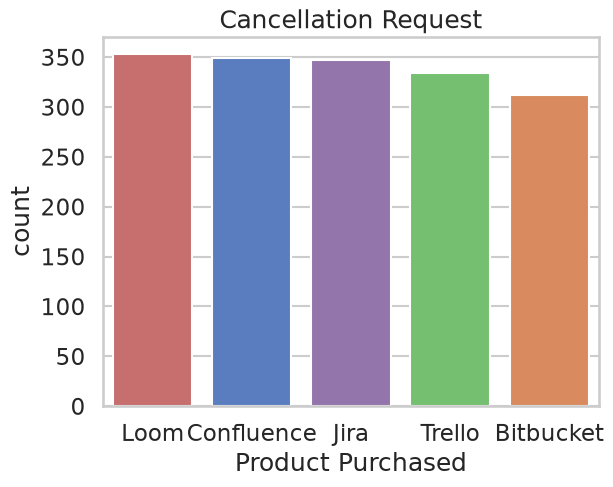

In [139]:
# Which product has the most amount of cancellation requests
sns.countplot(data=cancellation_requests,
              x="Product Purchased",
              hue="Product Purchased",
              order=["Loom", "Confluence", "Jira", "Trello", "Bitbucket"],
              hue_order=["Confluence","Bitbucket", "Trello", "Loom",  "Jira" ]).set_title("Cancellation Request")

## Find the percentage of cancellation requests per product

In [140]:
# get the all the requests
all = customer_support_tickets

# get the closed ones
cancellation = all[["Product Purchased", "Ticket Type"]]
cancellation_df = cancellation.groupby(["Product Purchased", "Ticket Type"]).size().reset_index(name="count")

# calculate the percentage within each Product Purchased group
cancellation_df["percentage"] = (
    cancellation_df.groupby("Product Purchased")["count"]
    .transform(lambda x: (x / x.sum()) * 100)
)
cancellation_df = cancellation_df.sort_values(["Product Purchased", "Ticket Type", "percentage"], ascending=False)
cancellation_df[cancellation_df["Ticket Type"] == "Cancellation request"].sort_values("percentage", ascending=False)


,Product Purchased,Ticket Type,count,percentage
16,Loom,Cancellation request,353,21.669736
21,Trello,Cancellation request,334,20.528580
1,Bitbucket,Cancellation request,312,19.561129
11,Jira,Cancellation request,347,19.418019
6,Confluence,Cancellation request,349,19.060623


In [141]:
cancellation_df.sort_values("Product Purchased", ascending=False)

,Product Purchased,Ticket Type,count,percentage
24,Trello,Technical issue,324,19.913952
23,Trello,Refund request,348,21.389060
22,Trello,Product inquiry,310,19.053473
21,Trello,Cancellation request,334,20.528580
20,Trello,Billing inquiry,311,19.114935
19,Loom,Technical issue,316,19.398404
18,Loom,Refund request,334,20.503376
17,Loom,Product inquiry,322,19.766728
16,Loom,Cancellation request,353,21.669736
15,Loom,Billing inquiry,304,18.661756


In [142]:
# get the all the requests
all = customer_support_tickets

# get the closed ones
closed = all[all["Ticket Status"] == "Closed"]
closed = all[["Product Purchased", "Ticket Type", "Ticket Subject", "Customer Satisfaction Rating"]]
closed_df = closed.groupby(["Product Purchased", "Ticket Type"])["Customer Satisfaction Rating"].mean().reset_index().sort_values(["Product Purchased", "Ticket Type", "Customer Satisfaction Rating"], ascending=True)
closed_df


,Product Purchased,Ticket Type,Customer Satisfaction Rating
0,Bitbucket,Billing inquiry,2.924731
1,Bitbucket,Cancellation request,3.109890
2,Bitbucket,Product inquiry,2.937500
3,Bitbucket,Refund request,2.896825
4,Bitbucket,Technical issue,2.892562
5,Confluence,Billing inquiry,3.037383
6,Confluence,Cancellation request,2.836957
7,Confluence,Product inquiry,3.000000
8,Confluence,Refund request,3.129032
9,Confluence,Technical issue,3.041322


In [143]:
closed_df[closed_df["Ticket Type"] == "Cancellation request"].sort_values("Customer Satisfaction Rating")

,Product Purchased,Ticket Type,Customer Satisfaction Rating
6,Confluence,Cancellation request,2.836957
16,Loom,Cancellation request,3.000000
21,Trello,Cancellation request,3.063636
1,Bitbucket,Cancellation request,3.109890
11,Jira,Cancellation request,3.125000


In [144]:
# get the all the requests
all = customer_support_tickets

# get the closed ones
closed = all[all["Ticket Status"] == "Closed"]
closed = all[["Product Purchased", "Ticket Type", "Ticket Subject", "Customer Satisfaction Rating"]]
closed_df = closed.groupby(["Product Purchased"])["Customer Satisfaction Rating"].mean().reset_index().sort_values(["Customer Satisfaction Rating"], ascending=True)
closed_df

,Product Purchased,Customer Satisfaction Rating
0,Bitbucket,2.944972
2,Jira,2.962264
4,Trello,2.974729
1,Confluence,3.017762
3,Loom,3.057196


### Refunds + Cancellations (Churn)

In [145]:
# get the all the requests
all = customer_support_tickets


refund_cancel = all[["Product Purchased", "Ticket Type"]]
refund_cancel["Churn"] = refund_cancel["Ticket Type"].isin(["Refund request", "Cancellation request"])
refund_cancel.drop(columns=["Ticket Type"])
refund_cancel_df = refund_cancel.groupby(["Product Purchased", "Churn"]).size().reset_index(name="count")

refund_cancel_df


,Product Purchased,Churn,count
0,Bitbucket,False,927
1,Bitbucket,True,668
2,Confluence,False,1105
3,Confluence,True,726
4,Jira,False,1103
5,Jira,True,684
6,Loom,False,942
7,Loom,True,687
8,Trello,False,945
9,Trello,True,682


In [146]:
# calculate the percentage within each Product Purchased group
refund_cancel_df["percentage"] = (
    refund_cancel_df.groupby("Product Purchased")["count"]
    .transform(lambda x: (x / x.sum()) * 100)
)

refund_cancel_df = refund_cancel_df.sort_values(["Product Purchased", "Churn", "percentage"], ascending=False)
refund_cancel_df[refund_cancel_df["Churn"]].sort_values("percentage", ascending=False)

,Product Purchased,Churn,count,percentage
7,Loom,True,687,42.173112
9,Trello,True,682,41.917640
1,Bitbucket,True,668,41.880878
3,Confluence,True,726,39.650464
5,Jira,True,684,38.276441


In [147]:
refund_cancel_df.sort_values("percentage", ascending=False)

,Product Purchased,Churn,count,percentage
4,Jira,False,1103,61.723559
2,Confluence,False,1105,60.349536
0,Bitbucket,False,927,58.119122
8,Trello,False,945,58.082360
6,Loom,False,942,57.826888
7,Loom,True,687,42.173112
9,Trello,True,682,41.917640
1,Bitbucket,True,668,41.880878
3,Confluence,True,726,39.650464
5,Jira,True,684,38.276441


In [148]:
# get the all the requests
all = customer_support_tickets

# get the closed ones
closed = all[all["Ticket Status"] == "Closed"]
closed["Churn"] = closed["Ticket Type"].isin(["Cancellation request", "Refund request"])

closed = closed[["Product Purchased", "Ticket Subject", "Churn", "Customer Satisfaction Rating"]]

closed_df = closed.groupby(["Product Purchased", "Churn"])["Customer Satisfaction Rating"].mean().reset_index().sort_values(["Customer Satisfaction Rating"], ascending=True)
closed_df[closed_df["Churn"]].sort_values("Customer Satisfaction Rating")


,Product Purchased,Churn,Customer Satisfaction Rating
7,Loom,True,2.906780
9,Trello,True,2.965368
1,Bitbucket,True,2.986175
3,Confluence,True,3.004630
5,Jira,True,3.037736


In [149]:
ticket_subjects_churn = closed[closed["Churn"]]
ticket_subjects_churn_loom = ticket_subjects_churn[ticket_subjects_churn["Product Purchased"] == "Loom"]

len(ticket_subjects_churn_loom)

236

In [150]:
import matplotlib.patches as mpatches

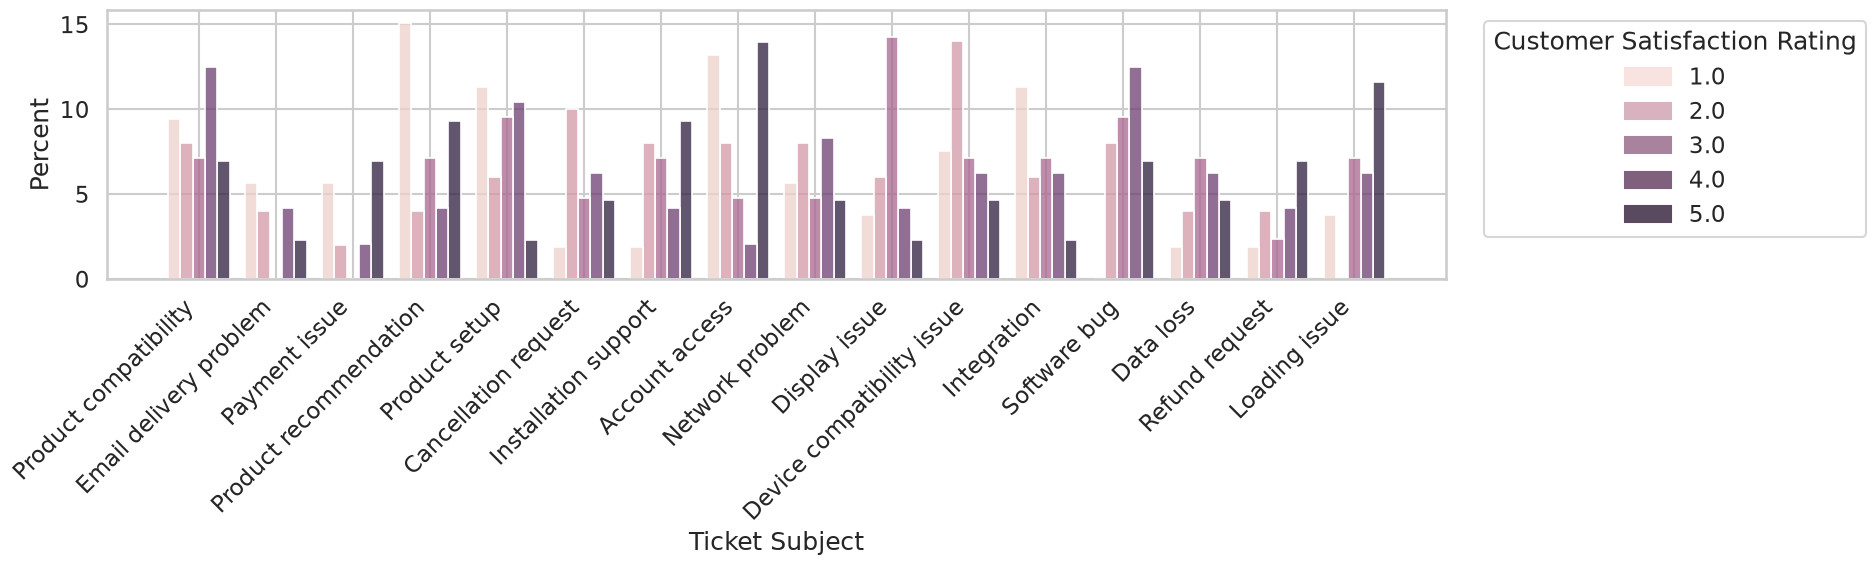

<Figure size 640x480 with 0 Axes>

In [151]:
plt.figure(figsize=(19, 6))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

ax = sns.histplot(
    data=ticket_subjects_churn_loom,
    hue="Customer Satisfaction Rating",
    x="Ticket Subject",
    multiple="dodge",
    shrink=0.8,
    common_norm=False,
    stat="percent"
)

handles, labels = ax.get_legend_handles_labels()
# 3. Manually define the legend handles since histplot handles can be empty
# (Using the soft pastel tones typical of this color palette)
colors = ["#f9e3e1", "#d8b2be", "#a9839d", "#7f607d", "#594a5f"]
ratings = ["1.0", "2.0", "3.0", "4.0", "5.0"]
patches = [
    mpatches.Patch(color=colors[i], label=ratings[i]) for i in range(len(ratings))
]

# 4. Place the legend cleanly outside the plot
plt.legend(
    handles=patches,
    title="Customer Satisfaction Rating",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)

plt.tight_layout()
plt.show()

# 5. Automatically adjust layout so rotated labels aren't cut off at the bottom
plt.tight_layout()
plt.show()

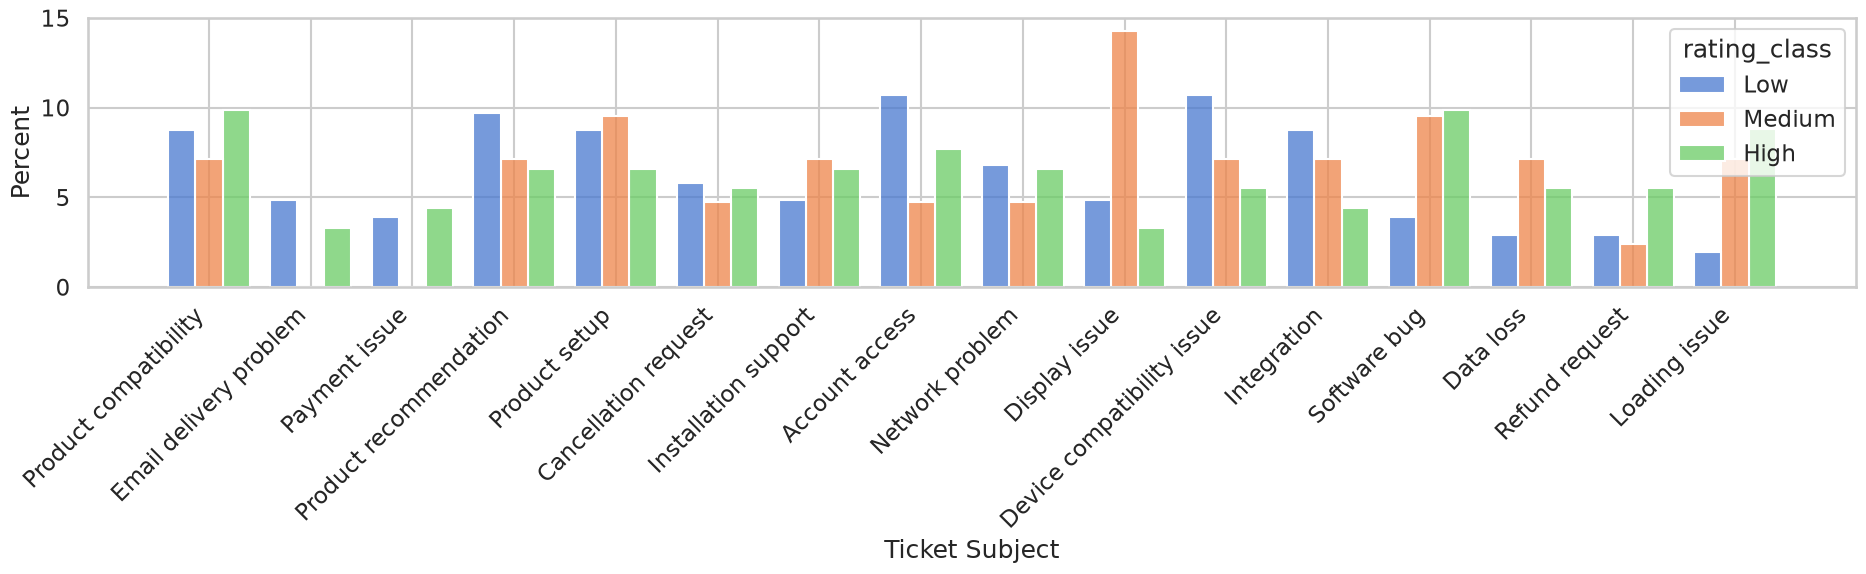

In [152]:
plt.figure(figsize=(19, 6))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

ticket_subjects_churn_loom["rating_class"] = ticket_subjects_churn_loom["Customer Satisfaction Rating"]
ticket_subjects_churn_loom["rating_class"] = ticket_subjects_churn_loom["rating_class"].replace(1.0, "Low")
ticket_subjects_churn_loom["rating_class"] = ticket_subjects_churn_loom["rating_class"].replace(2.0, "Low")
ticket_subjects_churn_loom["rating_class"] = ticket_subjects_churn_loom["rating_class"].replace(3.0, "Medium")
ticket_subjects_churn_loom["rating_class"] = ticket_subjects_churn_loom["rating_class"].replace(4.0, "High")
ticket_subjects_churn_loom["rating_class"] = ticket_subjects_churn_loom["rating_class"].replace(5.0, "High")


ax = sns.histplot(
    data=ticket_subjects_churn_loom,
    x="Ticket Subject",
    hue="rating_class",
    multiple="dodge",
    shrink=0.8,
    common_norm=False,
    stat="percent",
    hue_order=["Low", "Medium", "High"]
)


# 5. Automatically adjust layout so rotated labels aren't cut off at the bottom
plt.tight_layout()
plt.show()

### Figure out the average CSAT score per Ticket Subject

In [153]:
avg_rating_per_subject = ticket_subjects_churn_loom.groupby("Ticket Subject")["Customer Satisfaction Rating"].mean()
avg_rating_per_subject_df  = avg_rating_per_subject.reset_index(name="Average CSAT Score").sort_values("Average CSAT Score")
avg_rating_per_subject_df

,Ticket Subject,Average CSAT Score
7,Integration,2.375000
5,Email delivery problem,2.500000
3,Device compatibility issue,2.578947
13,Product setup,2.578947
12,Product recommendation,2.578947
0,Account access,2.750000
4,Display issue,2.785714
9,Network problem,2.866667
11,Product compatibility,2.904762
10,Payment issue,3.000000


### Use Bar Plot to Visualise the data

Text(0.5, 1.0, 'Average CSAT Score across Ticket Subject')

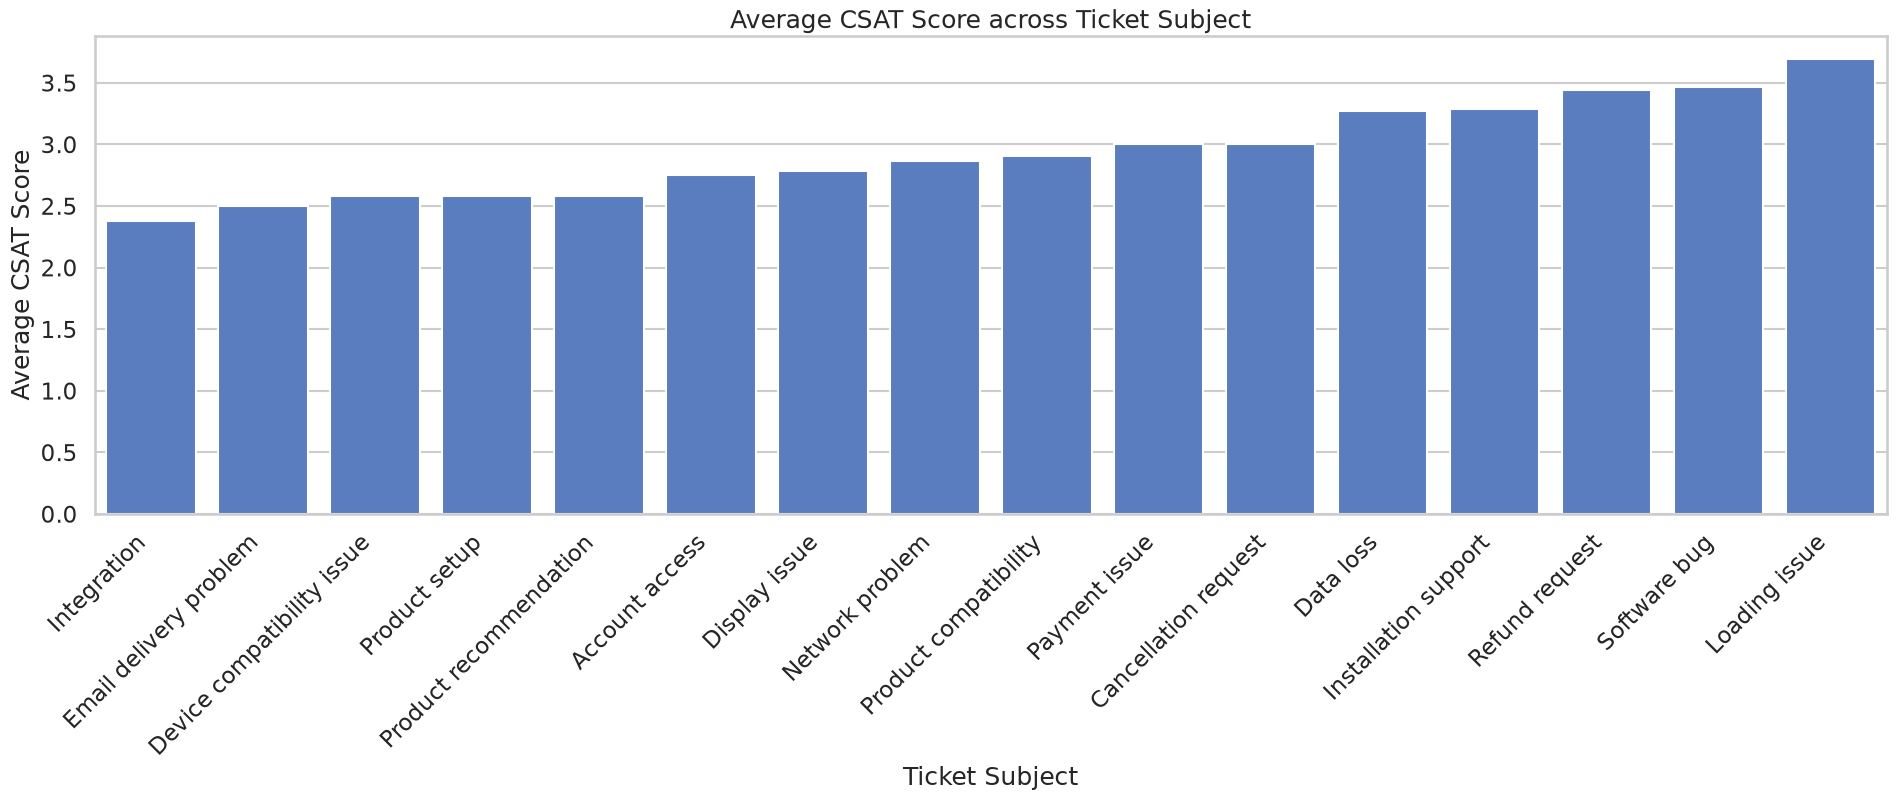

In [154]:
plt.figure(figsize=(19, 6))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

sns.barplot(
    data=avg_rating_per_subject_df,
    x="Ticket Subject",
    y="Average CSAT Score"
).set_title("Average CSAT Score across Ticket Subject")

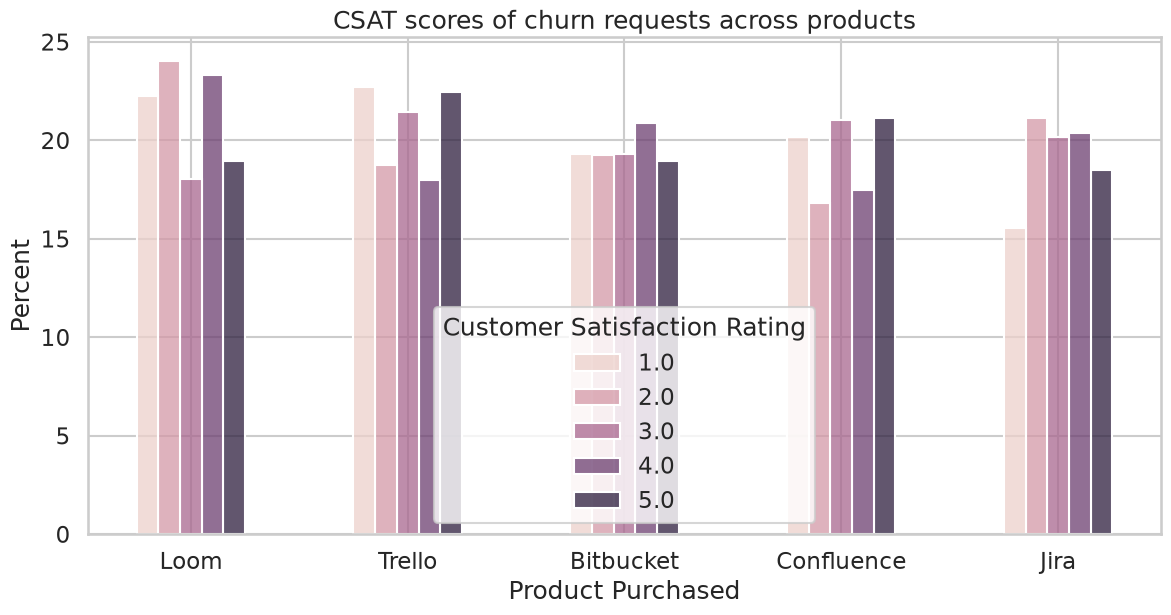

In [155]:
csat_data_across_products = closed[["Product Purchased", "Churn", "Customer Satisfaction Rating"]]
csat_data_across_products_churned = csat_data_across_products[csat_data_across_products["Churn"]]

# Define the correct chronological/logical order
size_order = ["Loom", "Trello", "Bitbucket", "Confluence", "Jira"]

# Convert the column to a categorical type with that specific order
csat_data_across_products_churned['Product Purchased'] = pd.Categorical(csat_data_across_products_churned['Product Purchased'], categories=size_order, ordered=True)

# Plot size/ ticks customisation
plt.figure(figsize=(12, 6))
plt.xticks(rotation=0, ha='center')
plt.tight_layout()

# Histplot using seaborn
sns.histplot(
    data=csat_data_across_products_churned,
    x="Product Purchased",
    hue="Customer Satisfaction Rating",
    multiple="dodge",
    shrink=0.5,
    common_norm=False,
    legend=True,
    stat="percent"
)



plt.title("CSAT scores of churn requests across products")
plt.show()

In [156]:
csat_data_across_products_churned.head()

,Product Purchased,Churn,Customer Satisfaction Rating
10,Bitbucket,True,1.0
19,Trello,True,5.0
29,Jira,True,1.0
33,Bitbucket,True,5.0
35,Jira,True,1.0


<Axes: xlabel='Product Purchased', ylabel='Customer Satisfaction Rating'>

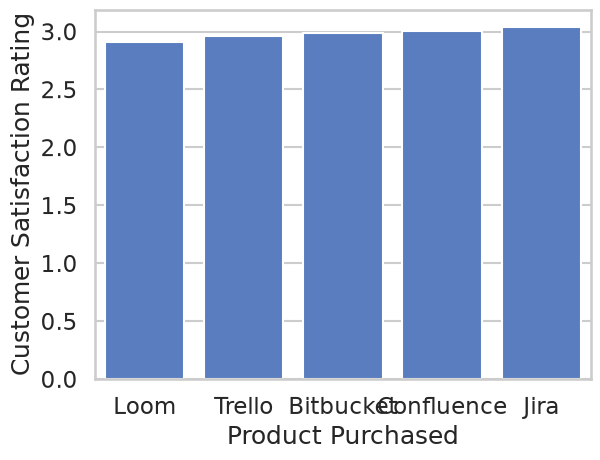

In [157]:
sns.barplot(
    data=closed_df[closed_df["Churn"]].sort_values("Customer Satisfaction Rating"),
    x="Product Purchased",
    y="Customer Satisfaction Rating"
)

In [158]:
closed_df[closed_df["Churn"] == False].sort_values("Customer Satisfaction Rating")

,Product Purchased,Churn,Customer Satisfaction Rating
0,Bitbucket,False,2.916129
4,Jira,False,2.919137
8,Trello,False,2.981424
2,Confluence,False,3.025937
6,Loom,False,3.173203


In [159]:
closed = customer_support_tickets[customer_support_tickets["Ticket Status"] == "Closed"]
print("Number of No-ratings in Closed Tickets")
int(closed["Customer Satisfaction Rating"].isna().sum())

Number of No-ratings in Closed Tickets


0

In [160]:
# get the all the requests
all = customer_support_tickets

# get the closed ones
closed = all[all["Ticket Status"] == "Closed"]
closed = all[["Product Purchased", "Ticket Type", "Ticket Subject", "Customer Satisfaction Rating"]]
closed_df = closed.groupby(["Product Purchased"])["Customer Satisfaction Rating"].mean().reset_index().sort_values(["Customer Satisfaction Rating"], ascending=True)
closed_df

,Product Purchased,Customer Satisfaction Rating
0,Bitbucket,2.944972
2,Jira,2.962264
4,Trello,2.974729
1,Confluence,3.017762
3,Loom,3.057196


# Findings:
 - Loom has the highest percentage of cancellation/refund requests.
 - The average customer satisfaction rating is pretty high for non-churn related requests (So is there a particular type of request that is dragging it down?)


# Goal:
 - What can we do to reduce the churn rate of Loom?
 - Why are the people cancelling?


In [161]:
loom = pd.read_csv(
    "customer_support_tickets.csv"
)

loom.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,Jira,22-03-2021,Technical issue,Product setup,Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,Confluence,22-05-2021,Technical issue,Integration,Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Trello,14-07-2020,Technical issue,Network problem,Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Loom,13-11-2020,Billing inquiry,Account access,Closed,Try capital clearly never color toward story.,Low,Social media,01-06-2023 07:29,01-06-2023 01:57,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Bitbucket,04-02-2020,Billing inquiry,Data loss,Closed,West decision evidence bit.,Low,Email,01-06-2023 00:12,01-06-2023 19:53,1.0


In [162]:
loom["Ticket Subject"].value_counts()

Ticket Subject
Refund request                576
Software bug                  574
Product compatibility         567
Email delivery problem        561
Device compatibility issue    547
Loading issue                 542
Network problem               539
Installation support          530
Product setup                 529
Payment issue                 526
Product recommendation        517
Account access                509
Integration                   496
Data loss                     491
Cancellation request          487
Display issue                 478
Name: count, dtype: int64

In [163]:
loom["Ticket Type"].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [164]:
loom = loom[["Product Purchased", "Ticket Subject", "Ticket Priority", "Ticket Channel", "Customer Satisfaction Rating", "Ticket Status"]]
loom = loom[loom["Product Purchased"] == "Loom"]
loom = loom[loom["Ticket Status"] == "Closed"]

avg_rating_subject = loom.groupby(
    "Ticket Subject"
)["Customer Satisfaction Rating"].mean()

avg_rating_subject = avg_rating_subject.reset_index(name="avg_rating")
avg_rating_subject = avg_rating_subject.sort_values("avg_rating", ascending=True)
avg_rating_subject


,Ticket Subject,avg_rating
3,Device compatibility issue,2.794118
5,Email delivery problem,2.833333
12,Product recommendation,2.842105
10,Payment issue,2.884615
13,Product setup,2.895833
4,Display issue,2.931034
0,Account access,2.947368
9,Network problem,2.950000
7,Integration,2.967742
14,Refund request,3.030303


In [165]:
count_rating_subject = loom.groupby(
    "Ticket Subject"
).size()

count_rating_subject = count_rating_subject.reset_index(name="count_rating")
count_rating_subject = count_rating_subject.sort_values("count_rating", ascending=False)
count_rating_subject


,Ticket Subject,count_rating
13,Product setup,48
11,Product compatibility,45
15,Software bug,45
9,Network problem,40
0,Account access,38
12,Product recommendation,38
6,Installation support,34
3,Device compatibility issue,34
14,Refund request,33
7,Integration,31


# Joins

In [166]:
customers = pd.read_csv("customers.csv")
customer_tickets = pd.read_csv("customer_support_tickets.csv")
merged_df = pd.merge(
    customer_tickets, 
    customers, 
    on=['Customer Email', 'Customer Name', 'Customer Age', 'Customer Gender'], 
    how='left'
)

In [167]:
loom_merged = merged_df[merged_df["Product Purchased"] == "Loom"]
loom_merged_ind_tickets = loom_merged[["Ticket Type", "Ticket Subject", "Ticket Status", "Customer Satisfaction Rating", "Industry", "Company Size", "Plan Type"]]
loom_merged_ind_tickets.head()

,Ticket Type,Ticket Subject,Ticket Status,Customer Satisfaction Rating,Industry,Company Size,Plan Type
3,Billing inquiry,Account access,Closed,3.0,Professional Services,51-200,Premium
5,Cancellation request,Payment issue,Open,NaN,Healthcare,51-200,Free
9,Refund request,Payment issue,Pending Customer Response,NaN,Financial Services,51-200,Standard
14,Billing inquiry,Product setup,Closed,4.0,Manufacturing,1-10,Premium
20,Refund request,Payment issue,Pending Customer Response,NaN,Media & Communications,1-10,Standard


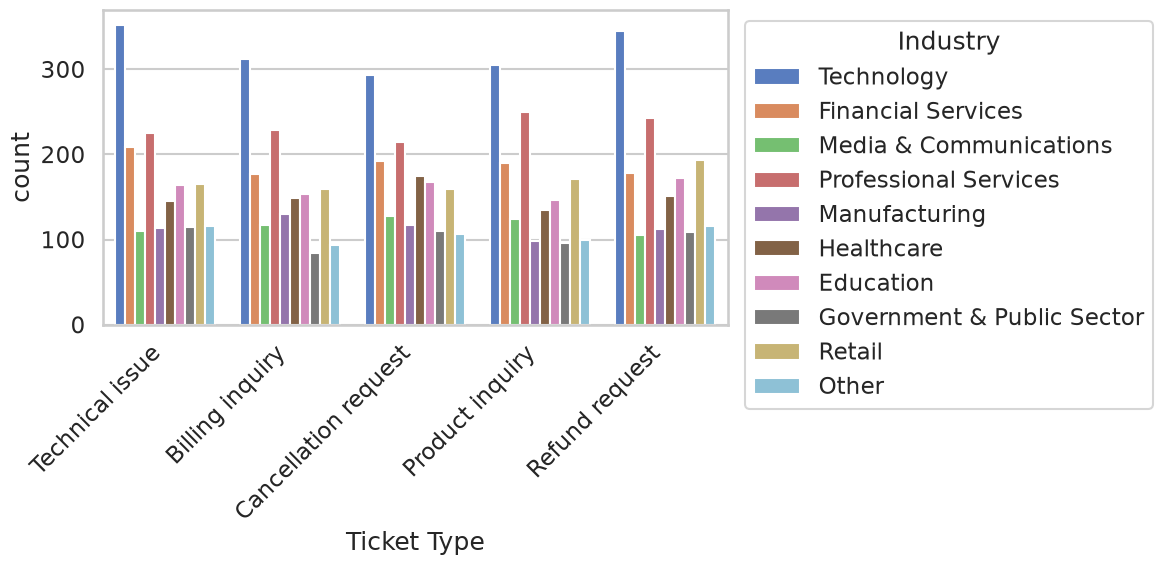

In [168]:
# 1. Increase the figure size to give the grouped bars more breathing room
plt.figure(figsize=(12, 6))

# 2. Generate the plot (assuming your dataframe is 'merged_df')
ax = sns.countplot(data=merged_df, x='Ticket Type', hue='Industry')

# 3. Rotate the x-axis labels 45 degrees so they don't overlap
plt.xticks(rotation=45, ha='right')

# 4. Move the legend outside the top right of the plot area
plt.legend(title='Industry', bbox_to_anchor=(1.01, 1), loc='upper left')

# 5. Automatically adjust subplots to fit the external legend and rotated labels
plt.tight_layout()

plt.show()

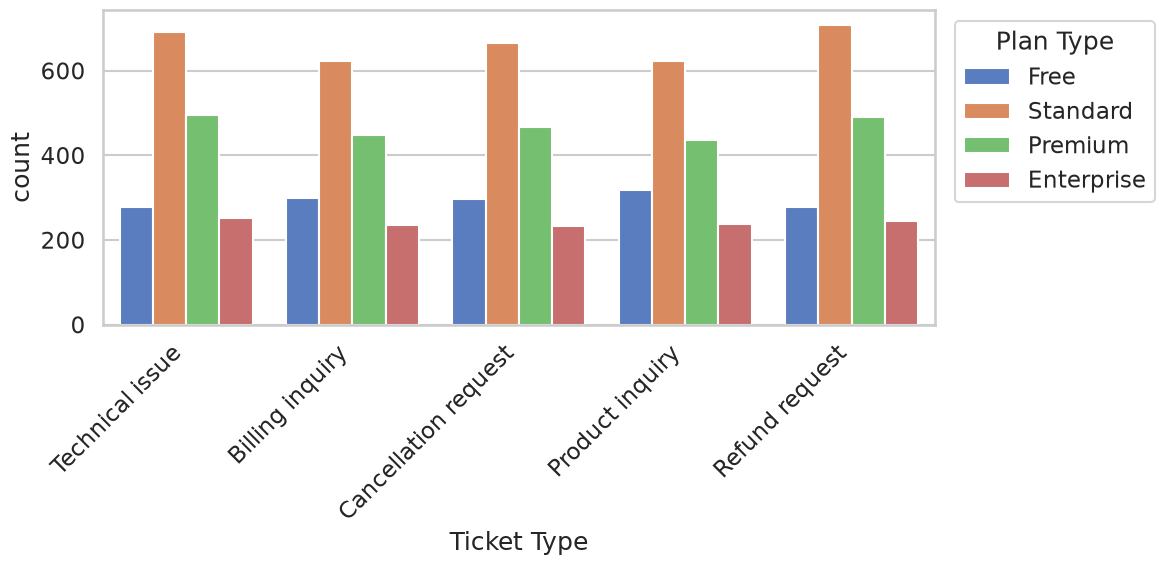

In [169]:
# 1. Increase the figure size to give the grouped bars more breathing room
plt.figure(figsize=(12, 6))

# 2. Generate the plot (assuming your dataframe is 'merged_df')
ax = sns.countplot(data=merged_df, x='Ticket Type', hue='Plan Type')

# 3. Rotate the x-axis labels 45 degrees so they don't overlap
plt.xticks(rotation=45, ha='right')

# 4. Move the legend outside the top right of the plot area
plt.legend(title='Plan Type', bbox_to_anchor=(1.01, 1), loc='upper left')

# 5. Automatically adjust subplots to fit the external legend and rotated labels
plt.tight_layout()

plt.show()

#### Plan Type Percentages

In [170]:
# get the closed ones
refund_cancel = loom_merged_ind_tickets[["Plan Type", "Ticket Type"]]
refund_cancel["Churn"] = refund_cancel["Ticket Type"].isin(["Refund request", "Cancellation request"])
refund_cancel.drop(columns=["Ticket Type"])
refund_cancel_df = refund_cancel.groupby(["Plan Type", "Churn"]).size().reset_index(name="count")

# calculate the percentage within each Product Purchased group
refund_cancel_df["percentage"] = (
    refund_cancel_df.groupby("Plan Type")["count"]
    .transform(lambda x: (x / x.sum()) * 100)
)

refund_cancel_df = refund_cancel_df.sort_values(["Plan Type", "Churn", "percentage"], ascending=False)
refund_cancel_df[refund_cancel_df["Churn"]].sort_values("percentage", ascending=False)

,Plan Type,Churn,count,percentage
5,Premium,True,190,43.181818
7,Standard,True,281,43.032159
1,Enterprise,True,92,39.826840
3,Free,True,109,38.790036


### Bar plot

Text(0.5, 1.0, 'Percentage of Churn Tickets across Plan Types')

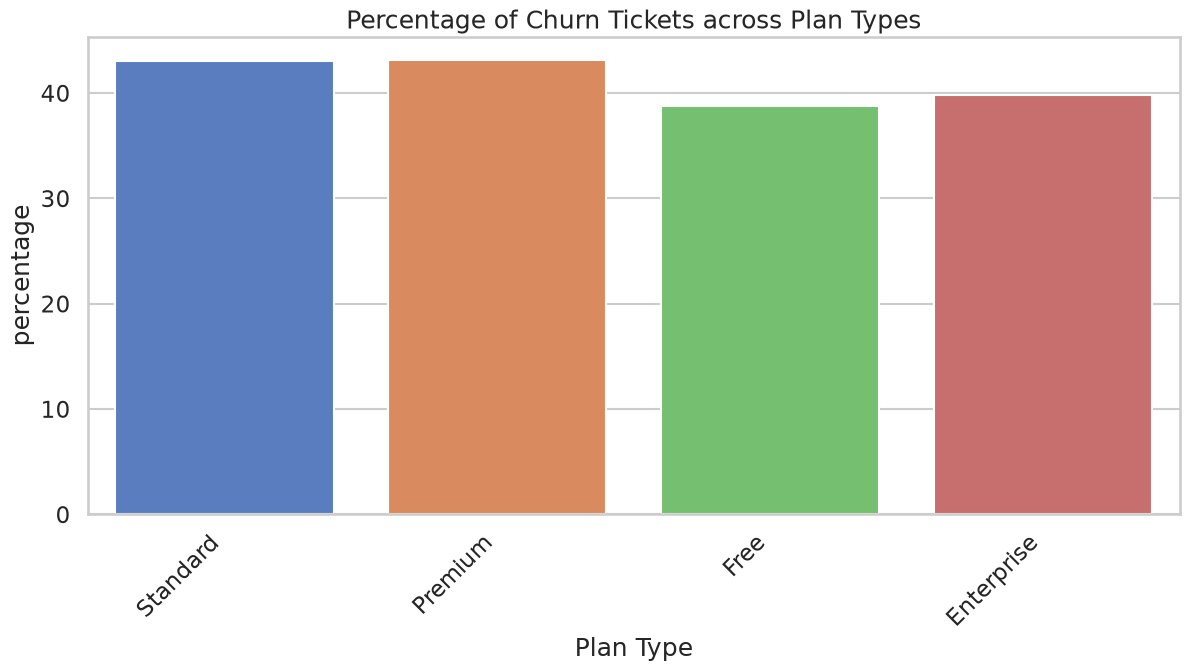

In [171]:
refund_cancel_df_plan_types = refund_cancel_df[refund_cancel_df["Churn"]]
refund_cancel_df_plan_types = refund_cancel_df_plan_types[["Plan Type", "percentage"]]
plt.figure(figsize=(12, 6))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
sns.barplot(data=refund_cancel_df_plan_types,
            x="Plan Type",
            y="percentage",
            hue="Plan Type").set_title("Percentage of Churn Tickets across Plan Types")

### Industry Percentages

In [172]:
# get the closed ones
refund_cancel = loom_merged_ind_tickets[["Industry", "Ticket Type"]]
refund_cancel["Churn"] = refund_cancel["Ticket Type"].isin(["Refund request", "Cancellation request"])
refund_cancel.drop(columns=["Ticket Type"])
refund_cancel_df = refund_cancel.groupby(["Industry", "Churn"]).size().reset_index(name="count")

# calculate the percentage within each Product Purchased group
refund_cancel_df["percentage"] = (
    refund_cancel_df.groupby("Industry")["count"]
    .transform(lambda x: (x / x.sum()) * 100)
)

refund_cancel_df = refund_cancel_df.sort_values(["Industry", "Churn", "percentage"], ascending=False)
refund_cancel_df[refund_cancel_df["Churn"]].sort_values("percentage", ascending=False)

,Industry,Churn,count,percentage
5,Government & Public Sector,True,46,48.421053
11,Media & Communications,True,50,47.169811
7,Healthcare,True,74,47.133758
1,Education,True,74,44.848485
17,Retail,True,74,43.274854
9,Manufacturing,True,42,41.176471
19,Technology,True,125,39.936102
15,Professional Services,True,86,38.738739
13,Other,True,38,38.000000
3,Financial Services,True,63,36.206897


In [173]:
refund_cancel_df.groupby("Industry")["count"].sum()

Industry
Education                     165
Financial Services            174
Government & Public Sector     95
Healthcare                    157
Manufacturing                 102
Media & Communications        106
Other                         100
Professional Services         222
Retail                        171
Technology                    313
Name: count, dtype: int64

Text(0.5, 1.0, 'Percentage of Churn Tickets across Industries')

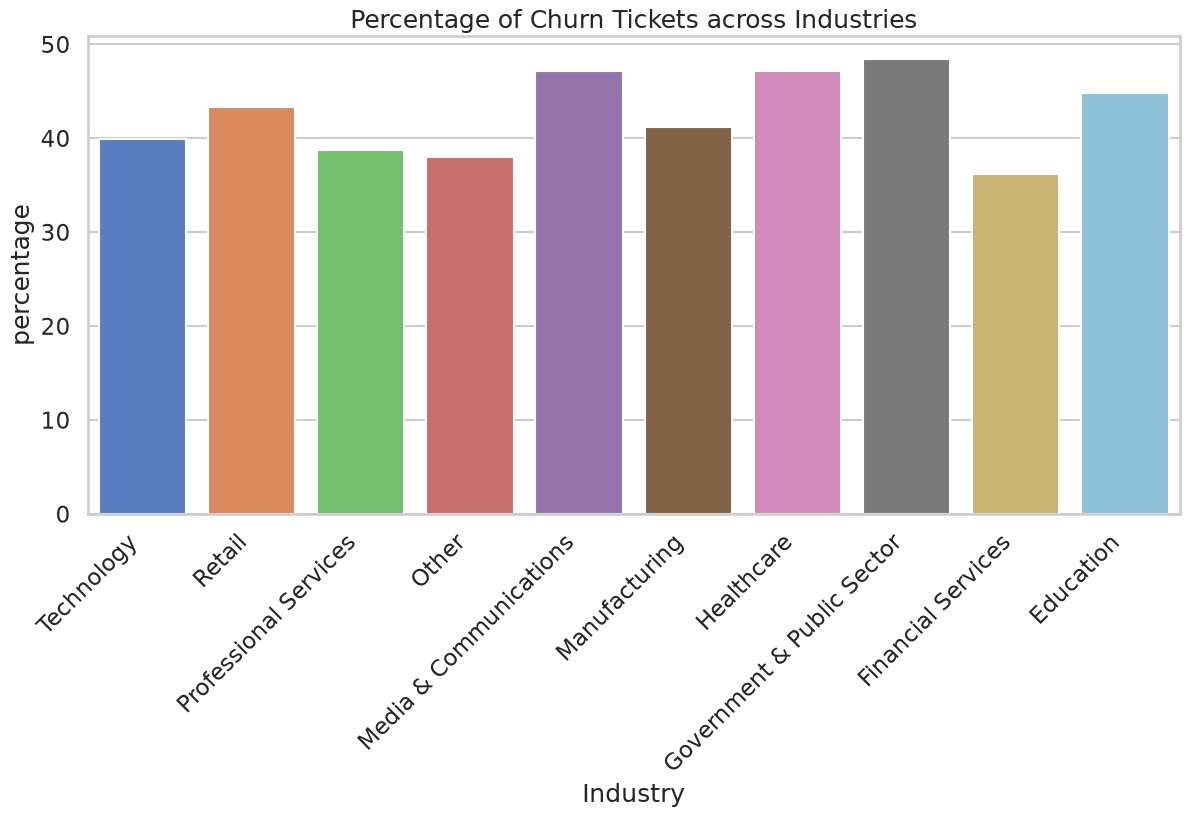

In [174]:
refund_cancel_df_plan_types = refund_cancel_df[refund_cancel_df["Churn"]]
refund_cancel_df_plan_types = refund_cancel_df_plan_types[["Industry", "percentage"]]
plt.figure(figsize=(12, 6))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
sns.barplot(data=refund_cancel_df_plan_types,
            x="Industry",
            y="percentage",
            hue="Industry").set_title("Percentage of Churn Tickets across Industries")

### Company Size Percentages

In [175]:
# get the closed ones
refund_cancel = loom_merged_ind_tickets[["Company Size", "Ticket Type"]]
refund_cancel["Churn"] = refund_cancel["Ticket Type"].isin(["Refund request", "Cancellation request"])
refund_cancel.drop(columns=["Ticket Type"])
refund_cancel_df = refund_cancel.groupby(["Company Size", "Churn"]).size().reset_index(name="count")

# calculate the percentage within each Product Purchased group
refund_cancel_df["percentage"] = (
    refund_cancel_df.groupby("Company Size")["count"]
    .transform(lambda x: (x / x.sum()) * 100)
)

refund_cancel_df = refund_cancel_df.sort_values(["Company Size", "Churn", "percentage"], ascending=False)
refund_cancel_df[refund_cancel_df["Churn"]].sort_values("percentage", ascending=False)

,Company Size,Churn,count,percentage
7,201-500,True,132,44.000000
5,11-50,True,148,42.898551
11,51-200,True,188,42.533937
3,1000+,True,78,41.935484
9,501-1000,True,61,38.125000
1,1-10,True,65,37.790698


In [176]:
refund_cancel_df.groupby("Company Size")["count"].sum()

Company Size
1-10        172
1000+       186
11-50       345
201-500     300
501-1000    160
51-200      442
Name: count, dtype: int64

In [177]:
refund_cancel_df.groupby("Company Size")["count"].sum().reset_index(name="count")["count"].sum()

np.int64(1605)

Text(0.5, 1.0, 'Percentage of Churn Tickets across Company Sizes')

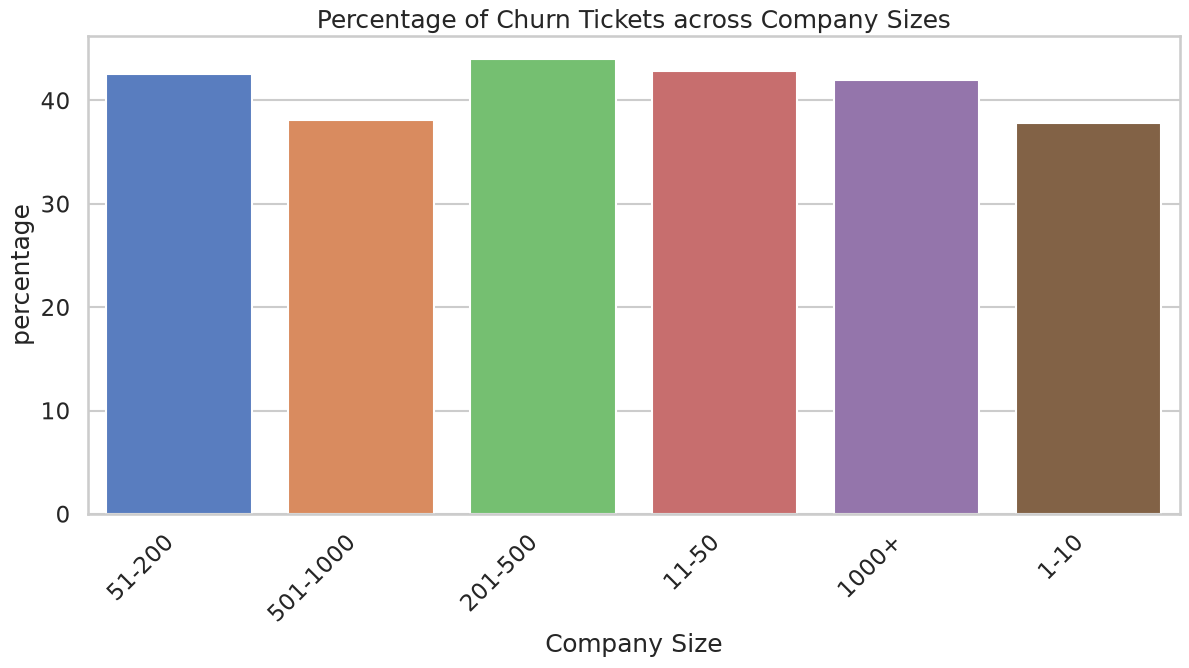

In [178]:
refund_cancel_df_plan_types = refund_cancel_df[refund_cancel_df["Churn"]]
refund_cancel_df_plan_types = refund_cancel_df_plan_types[["Company Size", "percentage"]]
plt.figure(figsize=(12, 6))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
sns.barplot(data=refund_cancel_df_plan_types,
            x="Company Size",
            y="percentage",
            hue="Company Size").set_title("Percentage of Churn Tickets across Company Sizes")

In [179]:
# Quick stats
customers = pd.read_csv("customers.csv")
tickets = pd.read_csv("customer_support_tickets.csv")

tickets = tickets[tickets["Product Purchased"] == "Loom"]

# Merge the datasets
customers_and_tickets = tickets.merge(
    customers,
    how="inner",
    on=['Customer Email', 'Customer Name', 'Customer Age', 'Customer Gender']
)



customers_and_tickets.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,...,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Customer ID,Industry,Region,Company Size,Plan Type,Account Created Date
0,4,Christina Dillon,bradleyolson@example.org,27,Female,Loom,13-11-2020,Billing inquiry,Account access,Closed,...,Social media,01-06-2023 07:29,01-06-2023 01:57,3.0,CUST00742,Professional Services,Australia & New Zealand,51-200,Premium,2019-06-19
1,6,Rebecca Fleming,sheenasmith@example.com,53,Male,Loom,28-07-2020,Cancellation request,Payment issue,Open,...,Social media,NaN,NaN,NaN,CUST06779,Healthcare,Europe,51-200,Free,2019-11-25
2,10,William Dawson,clopez@example.com,27,Male,Loom,06-03-2020,Refund request,Payment issue,Pending Customer Response,...,Phone,01-06-2023 09:25,NaN,NaN,CUST01352,Financial Services,Asia-Pacific,51-200,Standard,2019-08-13
3,15,Amy Hill,medinasteven@example.net,48,Female,Loom,29-02-2020,Billing inquiry,Product setup,Closed,...,Chat,01-06-2023 06:22,31-05-2023 23:08,4.0,CUST04930,Manufacturing,Australia & New Zealand,1-10,Premium,2018-12-05
4,21,Suzanne Holmes,rogermcgrath@example.net,28,Other,Loom,31-05-2021,Refund request,Payment issue,Pending Customer Response,...,Chat,01-06-2023 05:08,NaN,NaN,CUST06441,Media & Communications,North America,1-10,Standard,2020-09-19


In [180]:
customers_and_tickets["Explicit Churn"] = customers_and_tickets["Ticket Type"].isin(["Cancellation request", "Refund request"])
loom_customers = customers_and_tickets[["Customer ID", "Industry", "Company Size", "Plan Type", "Ticket Subject", "Explicit Churn"]]

loom_customers["Customer ID"].value_counts().reset_index(name="count")


,Customer ID,count
0,CUST00742,1
1,CUST06779,1
2,CUST01352,1
3,CUST04930,1
4,CUST06441,1
...,...,...
1600,CUST07311,1
1601,CUST02712,1
1602,CUST01257,1
1603,CUST00035,1
